# SAE 204 : BDD - Groupe

Dictionnaire des tables SQL

| table\_name | column\_name | data\_type | is\_nullable |
| :--- | :--- | :--- | :--- |
| controller | controllerid | integer | NO |
| controller | modelid | integer | NO |
| controller | serialnumber | text | NO |
| controlmeasurement | sensorid | integer | NO |
| controlmeasurement | controllerid | integer | NO |
| controlmeasurement | sensortimestamp | timestamp without time zone | NO |
| controlmeasurement | controltimestamp | timestamp without time zone | NO |
| controlmeasurement | controlvalue | double precision | NO |
| model | unit | text | NO |
| model | modelid | integer | NO |
| model | brand | text | NO |
| model | model | text | NO |
| model | name | text | NO |
| sensor | validity | interval | NO |
| sensor | sensorid | integer | NO |
| sensor | serialnumber | text | NO |
| sensor | position | text | NO |
| sensor | modelid | integer | NO |
| sensormeasurement | timestamp | timestamp without time zone | NO |
| sensormeasurement | sensorid | integer | NO |
| sensormeasurement | sensorvalue | double precision | NO |


Tester la connexion avec la base de données

In [15]:
import psycopg

conn_params = {
    "host": "localhost",
    "dbname": "postgres",
    "user": "postgres",
    "password": "admin"
}

try:
    with psycopg.connect(**conn_params) as conn:
        print("Connection successful!")
        with conn.cursor() as cur:
            cur.execute("SELECT version();")
            print(cur.fetchone())
except psycopg.OperationalError as e:
    print(f"Connection failed: {e}")


Connection successful!
('PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35225, 64-bit',)


Script 1 — Erreurs entre mesures manuelles et automatiques :

In [14]:
import psycopg


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as conn:
        with conn.cursor() as cur:
            cur.execute("""
                SELECT sensormeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue AS diff
                FROM controlmeasurement
                JOIN sensormeasurement
                    ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = 1
                ORDER BY controltimestamp
                LIMIT 50;
            """)

            for row in cur.fetchall():
                print(f"Sensor {row[0]} | Difference: {row[1]}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    get_sensor_difference(conn_params)

Sensor 1 | Difference: -0.6928256070072949
Sensor 1 | Difference: -0.42472458437324756
Sensor 1 | Difference: -0.19717837492203405
Sensor 1 | Difference: -0.05734016940635911
Sensor 1 | Difference: 0.14345425626137076
Sensor 1 | Difference: -0.37765161701976624
Sensor 1 | Difference: -0.38994523019952476
Sensor 1 | Difference: 0.4336675151979643
Sensor 1 | Difference: 0.7761312024213797
Sensor 1 | Difference: -0.15902853772262193
Sensor 1 | Difference: -0.0590040671430998
Sensor 1 | Difference: 0.4418077118033801
Sensor 1 | Difference: 0.5576625971798089
Sensor 1 | Difference: -0.02724000068365151
Sensor 1 | Difference: -0.0610747926891686
Sensor 1 | Difference: -0.14927230955878212
Sensor 1 | Difference: 0.3453796731956025
Sensor 1 | Difference: 0.565314546846384
Sensor 1 | Difference: 0.19167603339857386
Sensor 1 | Difference: 0.8958946595656778
Sensor 1 | Difference: -0.1490143137199928
Sensor 1 | Difference: -0.08535771270845571
Sensor 1 | Difference: -0.18043561924514262
Sensor 1 

Script 2 — Moyenne et écart-type :

In [13]:
import psycopg


def get_sensor_statistics(conn_params):
    try:
        with psycopg.connect(**conn_params) as conn:
            with conn.cursor() as cur:
                cur.execute("""
                    SELECT sensorid,
                           AVG(sensorvalue) AS moyenne,
                           STDDEV(sensorvalue) AS ecart_type
                    FROM sensormeasurement
                    WHERE sensorid = 1
                    GROUP BY sensorid;
                """)

                ligne = cur.fetchone()

                if ligne:
                    print(f"Sensor {ligne[0]} | Average: {ligne[1]:.10f} | StdDev: {ligne[2]:.10f}")
                else:
                    print("No data found for this sensor.")

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    get_sensor_statistics(conn_params)

Sensor 1 | Average: 0.0001409262 | StdDev: 1.2408729289


Carte de contrôle

Mean: -0.0037443199 | Standard deviation: 0.4127852187
Window: 8 days -> 33 points
Selected: 8 days (33 points)


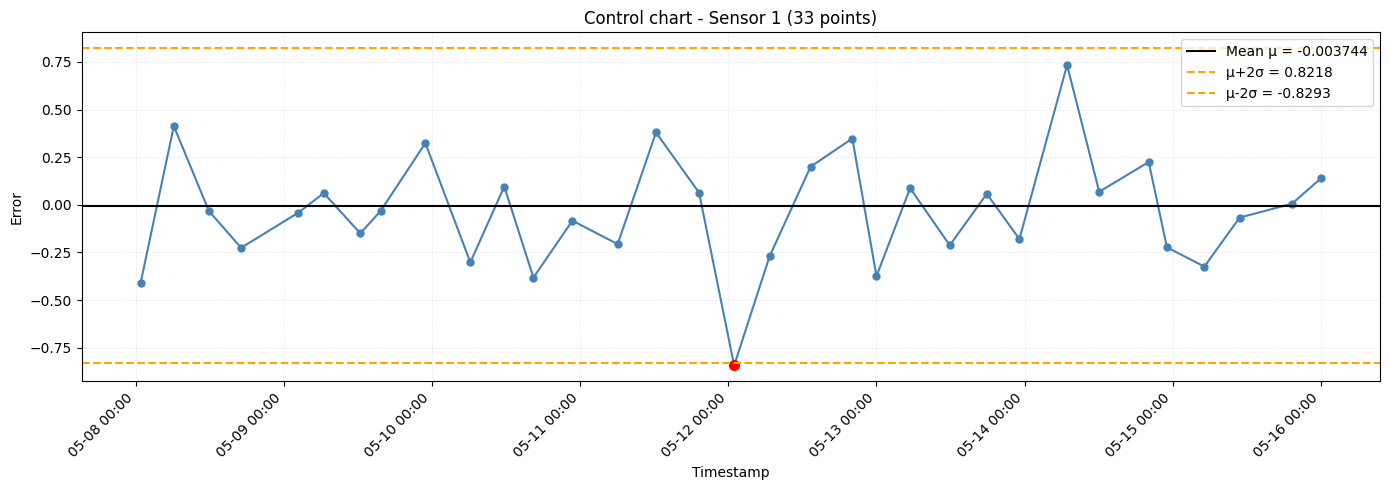

In [12]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SENSOR_ID = 1
MAX_POINTS = 100
MIN_POINTS = 20

conn_params = dict(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)


def get_sensor_statistics(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
            WHERE controlmeasurement.sensorid = %s
        """, (SENSOR_ID,))

        mean, standard_deviation = cursor.fetchone()

        if mean is None:
            return None, None

        print(f"Mean: {mean:.10f} | Standard deviation: {standard_deviation:.10f}")
        return float(mean), float(standard_deviation)


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()

        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (SENSOR_ID, days, SENSOR_ID, MAX_POINTS))

            rows = cursor.fetchall()
            print(f"Window: {days} days -> {len(rows)} points")

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                print(f"Selected: {days} days ({len(rows)} points)")
                return rows

        rows.reverse()
        return rows


def plot_chart(data, mean, standard_deviation):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', markersize=5)

    for timestamp, error in zip(timestamps, errors):
        if not (mean - 2 * standard_deviation <= error <= mean + 2 * standard_deviation):
            axis.plot(timestamp, error, 'ro', markersize=7)

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean μ = {mean:.6f}')
    axis.axhline(mean + 2 * standard_deviation, color='orange', linestyle='--',
                 label=f'μ+2σ = {mean + 2 * standard_deviation:.4f}')
    axis.axhline(mean - 2 * standard_deviation, color='orange', linestyle='--',
                 label=f'μ-2σ = {mean - 2 * standard_deviation:.4f}')

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axis.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axis.set_title(f'Control chart - Sensor {SENSOR_ID} ({len(data)} points)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    mean, standard_deviation = get_sensor_statistics(conn_params)
    data = get_sensor_difference(conn_params)

    if data and mean is not None:
        plot_chart(data, mean, standard_deviation)
    else:
        print("Unable to plot the chart: missing or insufficient data.")

Histogramme

--- SENSOR 1 ERROR STATS ---
Total points evaluated: 2005
Mean (µ): 0.003744 | Standard Deviation (σ): 0.412785

Q1: Points within [-1σ, +1σ]
Count: 1428 / 2005 -> 71.22% (Expected: ~68.27%)

Q2: Points within [-2σ, +2σ]
Count: 1903 / 2005 -> 94.91% (Expected: ~95.45%)

Q3: Points within [-3σ, +3σ]
Count: 1984 / 2005 -> 98.95% (Expected: ~99.73%)

Q4: Theoretical distribution of points OUTSIDE the intervals
Outside [-1σ, +1σ]: 100% - 68.27% = 31.73% (Experimental: 28.78%)
Outside [-2σ, +2σ]: 100% - 95.45% = 4.55% (Experimental: 5.09%)
Outside [-3σ, +3σ]: 100% - 99.73% = 0.27% (Experimental: 1.05%)



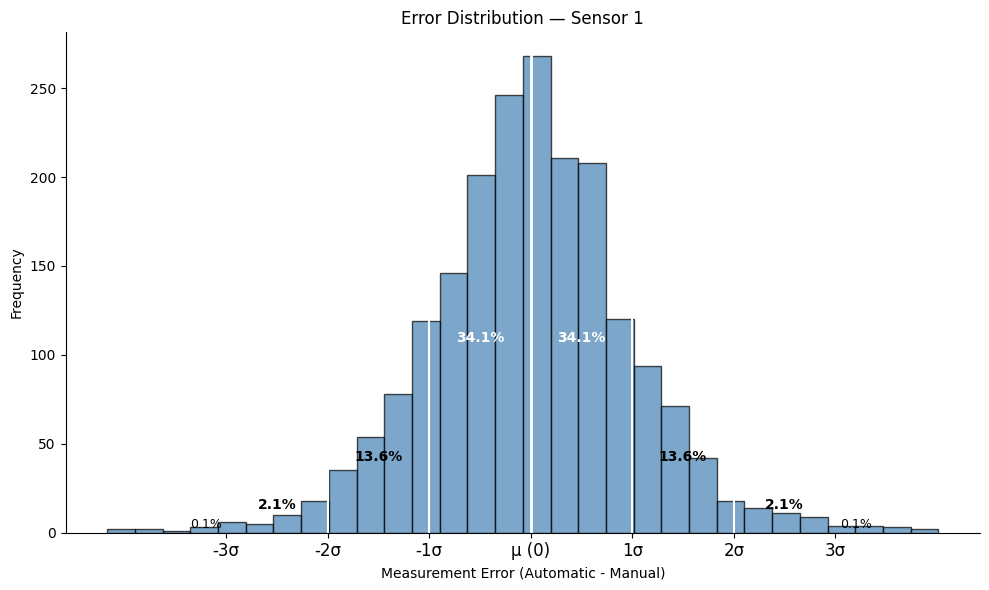

In [20]:
import psycopg
import matplotlib.pyplot as plt

def analyze_sensor_error(conn_params, sensor_id_to_test=1):
    try:
        with psycopg.connect(**conn_params) as conn:
            with conn.cursor() as cur:

                cur.execute("""
                    WITH ErrorData AS (
                        SELECT (sm.sensorvalue - cm.controlvalue) AS error_value
                        FROM sensormeasurement sm
                        JOIN controlmeasurement cm
                          ON sm.sensorid = cm.sensorid
                         AND sm.timestamp = cm.sensortimestamp
                        WHERE sm.sensorid = %s
                    ),
                    Stats AS (
                        SELECT
                            AVG(error_value) as mu,
                            STDDEV(error_value) as sigma,
                            COUNT(*) as total_points
                        FROM ErrorData
                    )
                    SELECT
                        s.mu,
                        s.sigma,
                        s.total_points,
                        COUNT(CASE WHEN e.error_value BETWEEN s.mu - s.sigma AND s.mu + s.sigma THEN 1 END) AS count_1sigma,
                        COUNT(CASE WHEN e.error_value BETWEEN s.mu - 2*s.sigma AND s.mu + 2*s.sigma THEN 1 END) AS count_2sigma,
                        COUNT(CASE WHEN e.error_value BETWEEN s.mu - 3*s.sigma AND s.mu + 3*s.sigma THEN 1 END) AS count_3sigma
                    FROM ErrorData e
                    CROSS JOIN Stats s
                    GROUP BY s.mu, s.sigma, s.total_points;
                """, (sensor_id_to_test,))

                row = cur.fetchone()

                if not row or row[0] is None:
                    print("No data found for this sensor.")
                    return

                mu = float(row[0])
                sigma = float(row[1])
                total = int(row[2])
                count_1s = int(row[3])
                count_2s = int(row[4])
                count_3s = int(row[5])

                print(f"--- SENSOR {sensor_id_to_test} ERROR STATS ---")
                print(f"Total points evaluated: {total}")
                print(f"Mean (µ): {mu:.6f} | Standard Deviation (σ): {sigma:.6f}\n")



                pct_1s = (count_1s / total) * 100
                print("Q1: Points within [-1σ, +1σ]")
                print(f"Count: {count_1s} / {total} -> {pct_1s:.2f}% (Expected: ~68.27%)\n")


                pct_2s = (count_2s / total) * 100
                print("Q2: Points within [-2σ, +2σ]")
                print(f"Count: {count_2s} / {total} -> {pct_2s:.2f}% (Expected: ~95.45%)\n")


                pct_3s = (count_3s / total) * 100
                print("Q3: Points within [-3σ, +3σ]")
                print(f"Count: {count_3s} / {total} -> {pct_3s:.2f}% (Expected: ~99.73%)\n")


                print("Q4: Theoretical distribution of points OUTSIDE the intervals")
                print(f"Outside [-1σ, +1σ]: 100% - 68.27% = 31.73% (Experimental: {100 - pct_1s:.2f}%)")
                print(f"Outside [-2σ, +2σ]: 100% - 95.45% = 4.55% (Experimental: {100 - pct_2s:.2f}%)")
                print(f"Outside [-3σ, +3σ]: 100% - 99.73% = 0.27% (Experimental: {100 - pct_3s:.2f}%)\n")

                cur.execute("""
                    SELECT (sm.sensorvalue - cm.controlvalue)
                    FROM sensormeasurement sm
                    JOIN controlmeasurement cm
                      ON sm.sensorid = cm.sensorid
                     AND sm.timestamp = cm.sensortimestamp
                    WHERE sm.sensorid = %s
                """, (sensor_id_to_test,))

                values = [r[0] for r in cur.fetchall()]

                plot_histogram(values, mu, sigma, sensor_id_to_test)

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


def plot_histogram(values, mu, sigma, sensor_id):
    plt.figure(figsize=(10, 6))

    counts, bins, patches = plt.hist(values, bins=30, edgecolor='black', color='steelblue', alpha=0.7)

    max_y = max(counts)

    plt.axvline(mu, color='white', linewidth=2)
    plt.axvline(mu - sigma, color='white', linewidth=1.5)
    plt.axvline(mu + sigma, color='white', linewidth=1.5)
    plt.axvline(mu - 2*sigma, color='white', linewidth=1.5)
    plt.axvline(mu + 2*sigma, color='white', linewidth=1.5)

    plt.text(mu - 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)
    plt.text(mu + 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)

    plt.text(mu - 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)
    plt.text(mu + 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)

    plt.text(mu - 2.5 * sigma, max_y * 0.05, '2.1%', ha='center', color='black', fontweight='bold', fontsize=10)
    plt.text(mu + 2.5 * sigma, max_y * 0.05, '2.1%', ha='center', color='black', fontweight='bold', fontsize=10)

    plt.text(mu - 3.2 * sigma, max_y * 0.01, '0.1%', ha='center', color='black', fontsize=9)
    plt.text(mu + 3.2 * sigma, max_y * 0.01, '0.1%', ha='center', color='black', fontsize=9)

    ticks = [mu - 3*sigma, mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma, mu + 3*sigma]
    labels = ['-3σ', '-2σ', '-1σ', 'µ (0)', '1σ', '2σ', '3σ']
    plt.xticks(ticks, labels, fontsize=12)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel('Measurement Error (Automatic - Manual)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution — Sensor {sensor_id}')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    analyze_sensor_error(conn_params, 1)

Droite de régression

Calculated drift threshold (slope) for p < 0.05: 0.088721
PASS - No drift detected. Current slope (0.0218) is within normal bounds (< 0.0887).


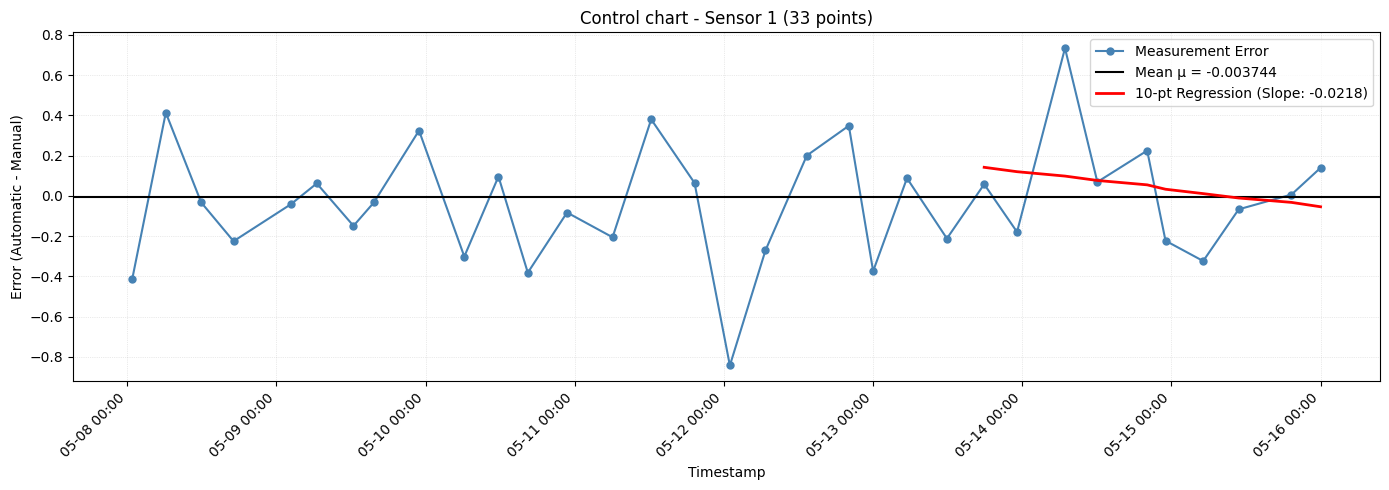

In [33]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

SENSOR_ID = 1
MAX_POINTS = 100
MIN_POINTS = 20

conn_params = dict(
    host="localhost",
    dbname="postgres",
    user="postgres",
    password="admin"
)

def get_sensor_statistics(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
            WHERE controlmeasurement.sensorid = %s
        """, (SENSOR_ID,))

        mean, standard_deviation = cursor.fetchone()

        if mean is None:
            return None, None

        return float(mean), float(standard_deviation)


def get_sensor_difference(conn_params):
    with psycopg.connect(**conn_params) as connection:
        cursor = connection.cursor()

        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.sensorid,
                       controlmeasurement.controlvalue - sensormeasurement.sensorvalue,
                       controlmeasurement.controltimestamp
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (SENSOR_ID, days, SENSOR_ID, MAX_POINTS))

            rows = cursor.fetchall()

            if len(rows) >= MIN_POINTS:
                rows.reverse()
                return rows

        rows.reverse()
        return rows


def calculate_drift_threshold(sigma, p_value=0.05, simulations=100000):
    x = np.arange(10)
    slopes = []

    for _ in range(simulations):
        random_errors = np.random.normal(loc=0.0, scale=sigma, size=10)
        slope, _ = np.polyfit(x, random_errors, 1)
        slopes.append(abs(slope))

    percentile = (1 - p_value) * 100
    threshold = np.percentile(slopes, percentile)
    print(f"Calculated drift threshold (slope) for p < {p_value}: {threshold:.6f}")
    return threshold


def plot_chart(data, mean, standard_deviation, drift_threshold):
    timestamps = [row[2] for row in data]
    errors = [float(row[1]) for row in data]

    figure, axis = plt.subplots(figsize=(14, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', markersize=5, label='Measurement Error')

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean μ = {mean:.6f}')

    if len(errors) >= 10:
        last_10_errors = errors[-10:]
        last_10_timestamps = timestamps[-10:]
        x_indices = np.arange(10)

        slope, intercept = np.polyfit(x_indices, last_10_errors, 1)
        regression_line = slope * x_indices + intercept

        axis.plot(last_10_timestamps, regression_line, color='red', linewidth=2,
                  label=f'10-pt Regression (Slope: {slope:.4f})')

        # Check rule
        if abs(slope) > drift_threshold:
            print(f"ALARM - Drift Rule triggered: Slope of last 10 points ({abs(slope):.4f}) exceeds threshold ({drift_threshold:.4f}).")
        else:
            print(f"PASS - No drift detected. Current slope ({abs(slope):.4f}) is within normal bounds (< {drift_threshold:.4f}).")

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    axis.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')

    axis.set_title(f'Control chart - Sensor {SENSOR_ID} ({len(data)} points)')
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Error (Automatic - Manual)')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    mean, standard_deviation = get_sensor_statistics(conn_params)
    data = get_sensor_difference(conn_params)

    if data and mean is not None:
        drift_threshold = calculate_drift_threshold(standard_deviation, p_value=0.05)
        plot_chart(data, mean, standard_deviation, drift_threshold)
    else:
        print("Unable to plot the chart: missing or insufficient data.")